# Two-Body Reference

API reference covering all public functions with a 2D Kepler problem.

In [1]:
using WeberElectrodynamics
using Symbolics
using LinearAlgebra


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## Hamiltonian

Two-body Kepler problem:
$$H = \frac{|\mathbf{p}_1|^2}{2m_1} + \frac{|\mathbf{p}_2|^2}{2m_2} - \frac{Gm_1m_2}{|\mathbf{r}_1 - \mathbf{r}_2|}$$

In [2]:
n_particles = 2
dims = 2

q_syms, p_syms = create_phase_space_variables(n_particles, dims)
param_names = [:m1, :m2, :G]

function H_kepler(q, p, params)
    m1, m2, G = params
    x1, y1, x2, y2 = q
    px1, py1, px2, py2 = p
    
    KE = (px1^2 + py1^2)/(2m1) + (px2^2 + py2^2)/(2m2)
    r = sqrt((x1 - x2)^2 + (y1 - y2)^2)
    PE = -G * m1 * m2 / r
    
    return KE + PE
end

sh = symbolize(H_kepler, q_syms, p_syms, param_names)
vf = compile(sh)
;

In [3]:
sh.H_sym

(px2^2 + py2^2) / (2m2) + (px1^2 + py1^2) / (2m1) + (-G*m1*m2) / sqrt((x1 - x2)^2 + (y1 - y2)^2)

In [4]:
sh.qdot_sym[1]

px1 / m1

In [5]:
sh.pdot_sym[1]

(-G*m1*m2*(x1 - x2)) / (((x1 - x2)^2 + (y1 - y2)^2)*sqrt((x1 - x2)^2 + (y1 - y2)^2))

## Initial Conditions

Circular orbit: $v = \sqrt{GM/r}$ for reduced mass at separation $r$.

In [6]:
m1, m2, G = 1.0, 0.5, 1.0
params = [m1, m2, G]

r0 = 2.0
M = m1 + m2
v_circ = sqrt(G * M / r0)

r1 = -m2/M * r0
r2 = m1/M * r0
v_scale = 0.7
v1 = -m2/M * v_circ * v_scale
v2 = m1/M * v_circ * v_scale

q0 = [r1, 0.0, r2, 0.0]
p0 = [0.0, m1*v1, 0.0, m2*v2]

point = PhaseSpacePoint(q0, p0)
settings = IntegratorSettings(0.01, 1e-12, 100)
state = IntegratorState(point, settings, vf, params)
;

## Integration

In [7]:
T = 2π * sqrt(r0^3 / (G * M))
timespan = TimeSpan(0.0, 2T)

sol = integrate(state, timespan)

println("Steps: ", length(sol.t))
println("Final q: ", round.(sol.q[end], digits=6))

Steps: 2904
Final q: [-0.336588, 0.367747, 0.673176, -0.735494]

Final q: [-0.336588, 0.367747, 0.673176, -0.735494]


## Single Step

Demonstrating `step!` for manual stepping.

In [8]:
test_state = IntegratorState(PhaseSpacePoint(copy(q0), copy(p0)), settings, vf, params)
step!(test_state)
println("After one step: q = ", round.(test_state.point.q, digits=6))

After one step: q = [-0.339621, 0.367058, 0.679241, -0.734116]


## Trajectories

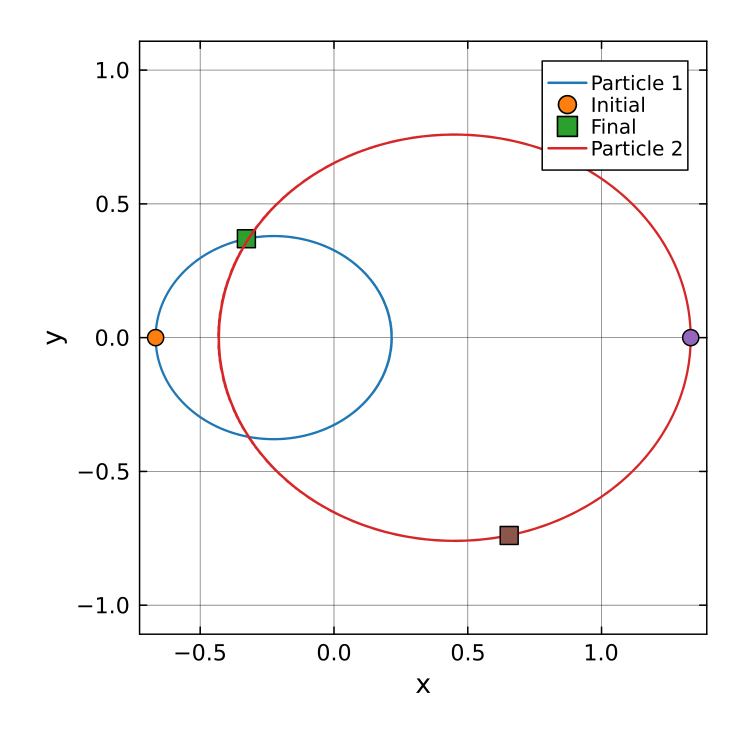

In [9]:
traj = create_trajectory_data(sol, n_particles, dims; stride=10)
plot_trajectories(traj)

## Energy Conservation

Max local error: 2.1939092186451514e-5
Relative range: -0.00011623426668504766


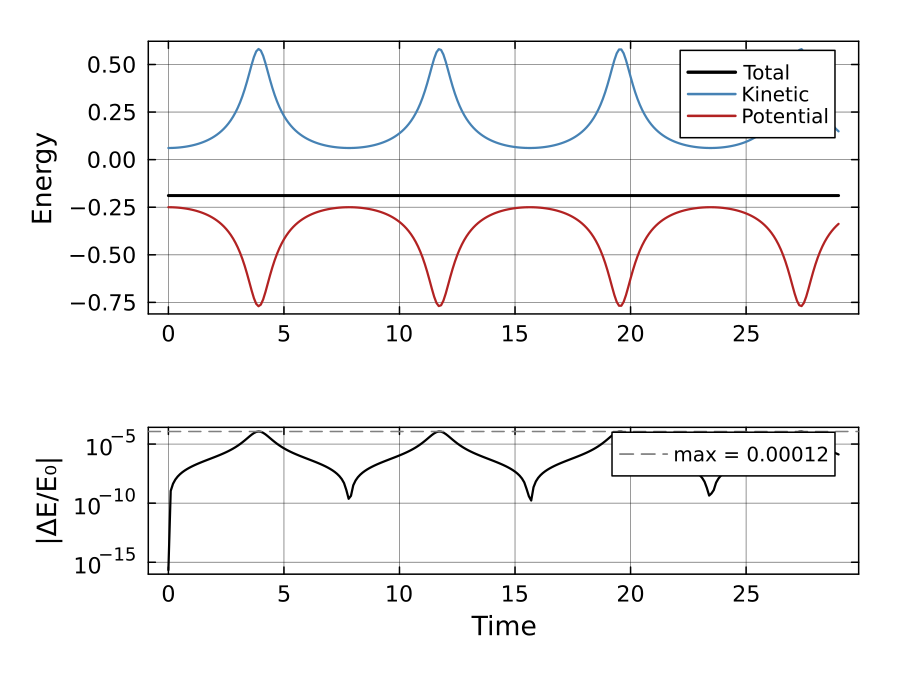

In [10]:
function total_energy(q, p, params, t)
    H_kepler(q, p, params)
end

function kinetic_energy(q, p, params, t)
    m1, m2, _ = params
    px1, py1, px2, py2 = p
    (px1^2 + py1^2)/(2m1) + (px2^2 + py2^2)/(2m2)
end

function potential_energy(q, p, params, t)
    m1, m2, G = params
    x1, y1, x2, y2 = q
    r = sqrt((x1 - x2)^2 + (y1 - y2)^2)
    -G * m1 * m2 / r
end

energy = compute_energy_timeseries(sol, total_energy, kinetic_energy, potential_energy, params; stride=10)

println("Max local error: ", energy.max_local_error)
println("Relative range: ", energy.relative_energy_range)

plot_energy(energy)

## Force Analysis

Weber force with $c \to \infty$ recovers Coulomb/Newton.

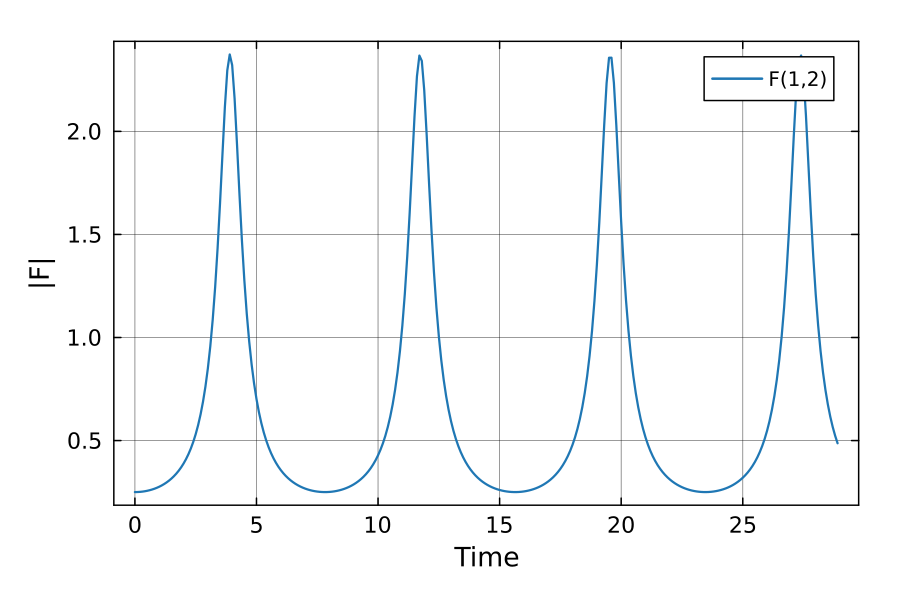

In [11]:
masses = [m1, m2]
charges = [1.0, 1.0]
c = 1e6

forces = compute_force_timeseries(sol, n_particles, dims, masses, charges, c; stride=10)

plot_forces(forces)